In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/used_cars.csv")

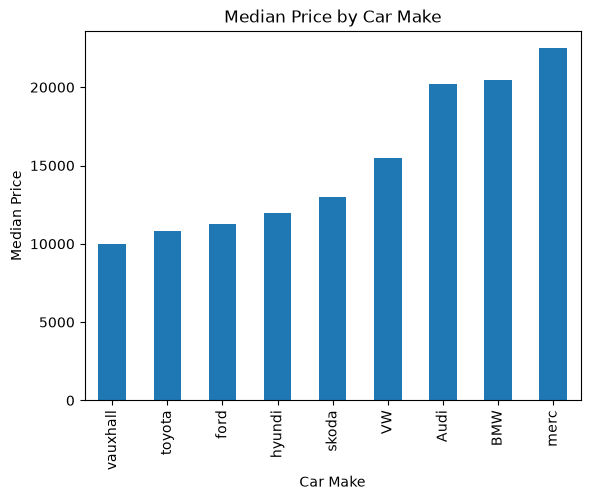

In [3]:
df.groupby("Make")["price"].median().sort_values().plot(kind="bar")

plt.xlabel("Car Make")
plt.ylabel("Median Price")
plt.title("Median Price by Car Make")
plt.show()

### Price by Car Make

The median price varies across car makes.
Some brands have noticeably higher typical used-car prices,
while others are positioned in lower price ranges.
This suggests that car make is an important factor in used-car pricing.

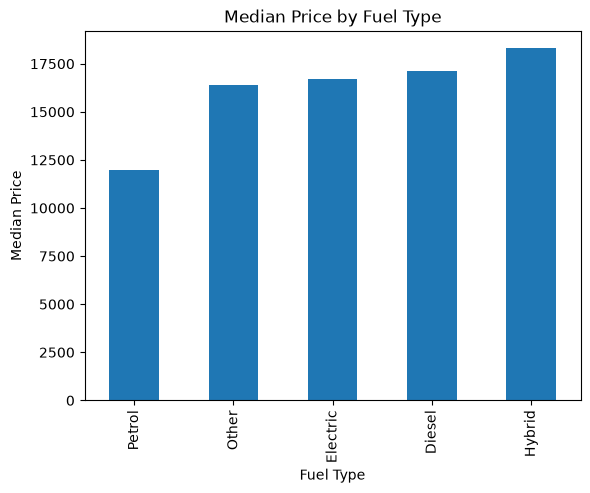

In [4]:
df.groupby("fuelType")["price"].median().sort_values().plot(kind="bar")

plt.xlabel("Fuel Type")
plt.ylabel("Median Price")
plt.title("Median Price by Fuel Type")
plt.show()

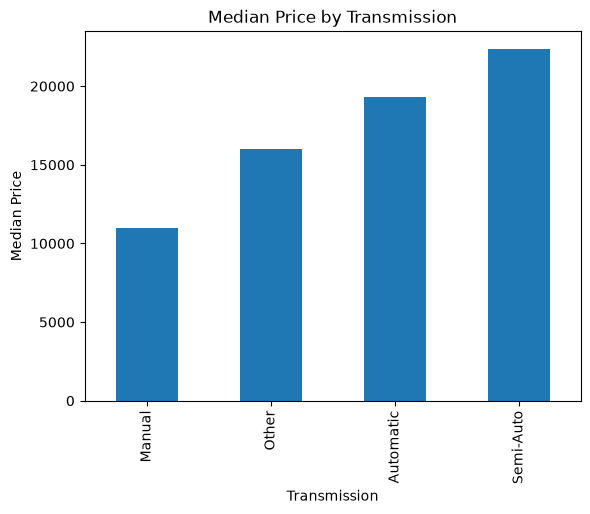

In [5]:
df.groupby("transmission")["price"].median().sort_values().plot(kind="bar")

plt.xlabel("Transmission")
plt.ylabel("Median Price")
plt.title("Median Price by Transmission")
plt.show()

In [6]:
df["Make"].value_counts().head(15)

Make
ford        17965
VW          15157
vauxhall    13632
merc        13119
BMW         10781
Audi        10668
toyota       6738
skoda        6267
hyundi       4860
Name: count, dtype: int64

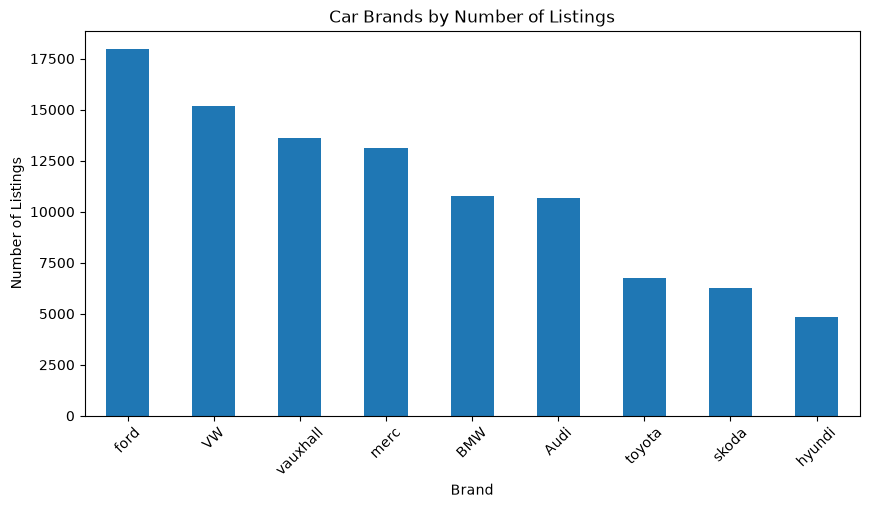

In [7]:
df["Make"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Car Brands by Number of Listings")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

### Insight

The used-car dataset is concentrated around a small number of brands. Ford has the highest number of listings, followed by Volkswagen, Vauxhall, and Mercedes. This indicates that these brands have the strongest representation in the dataset and should receive greater attention in later market and recommendation analysis.

In [8]:
df["model"].value_counts().head(15)

model
Fiesta      6557
Golf        4863
Focus       4588
C Class     3747
Corsa       3441
Polo        3287
Astra       2805
A Class     2561
3 Series    2443
Kuga        2225
Mokka X     2127
Yaris       2122
1 Series    1969
Aygo        1961
E Class     1953
Name: count, dtype: int64

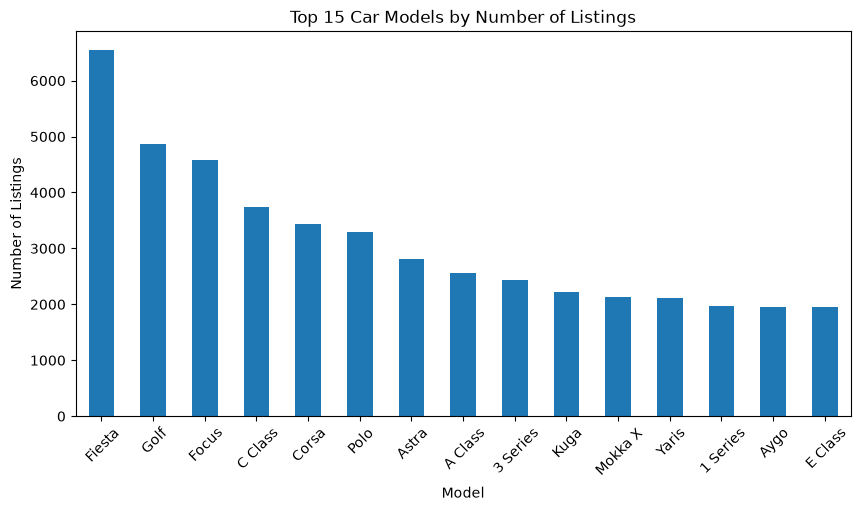

In [9]:
df["model"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 15 Car Models by Number of Listings")
plt.xlabel("Model")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

### Insight

The dataset is concentrated among a relatively small number of models. The Ford Fiesta has the highest number of listings, followed by the Volkswagen Golf and Ford Focus. This shows that these models have strong representation in the dataset and provides a useful basis for deeper model-level price and value analysis.

In [10]:
df.groupby(["Make", "model"]).size().sort_values(ascending=False).head(20)

Make      model   
ford      Fiesta      6557
VW        Golf        4863
ford      Focus       4588
merc      C Class     3747
vauxhall  Corsa       3441
VW        Polo        3287
vauxhall  Astra       2805
merc      A Class     2561
BMW       3 Series    2443
ford      Kuga        2225
vauxhall  Mokka X     2127
toyota    Yaris       2122
BMW       1 Series    1969
toyota    Aygo        1961
merc      E Class     1953
Audi      A3          1929
VW        Tiguan      1765
skoda     Fabia       1571
          Octavia     1477
Audi      Q3          1417
dtype: int64

### Insight

The market is concentrated around a small number of brand–model combinations. The Ford Fiesta has the highest representation with 6,557 listings, followed by the Volkswagen Golf and Ford Focus. This suggests that model-level analysis will be important for understanding used-car market patterns and building the future recommendation system.

In [11]:
popular_models = df["model"].value_counts().head(15).index

df[df["model"].isin(popular_models)].groupby("model")["price"].median().sort_values()

model
Aygo         7895.0
Corsa        7999.0
Fiesta       9995.0
Astra       10298.0
Yaris       10652.5
Polo        10750.0
Mokka X     12435.0
Focus       12790.0
1 Series    14800.0
Kuga        15980.0
Golf        16000.0
A Class     18240.0
3 Series    18299.0
E Class     22980.0
C Class     22999.0
Name: price, dtype: float64

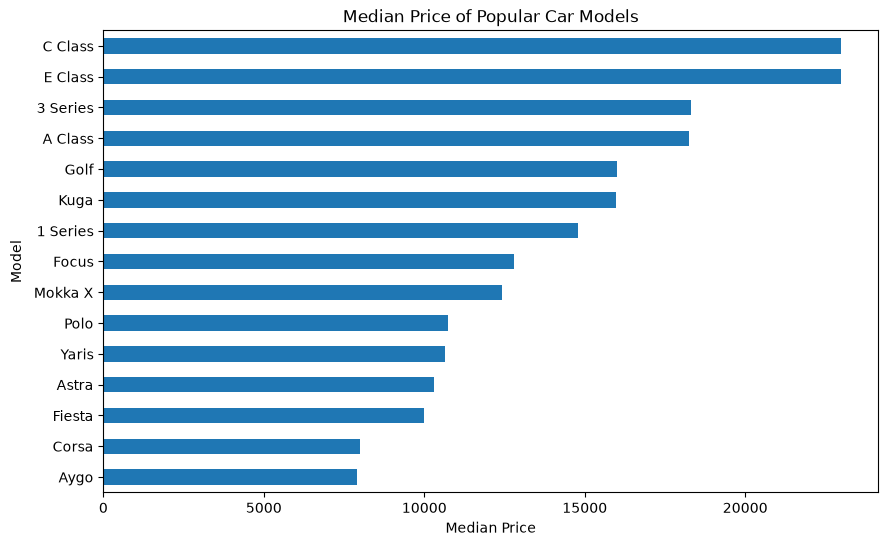

In [12]:
model_prices = (
    df[df["model"].isin(popular_models)]
    .groupby("model")["price"]
    .median()
    .sort_values()
)

model_prices.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Median Price of Popular Car Models")
plt.xlabel("Median Price")
plt.ylabel("Model")

plt.show()

### Insight

Popular models show substantial differences in median used-car prices. The Aygo and Corsa occupy the lower-priced end of the market, while the Mercedes C Class and E Class are positioned at the higher end. This variation indicates that model choice is an important factor in determining the budget required for a used car.

In [13]:
df["price_segment"] = pd.cut(
    df["price"],
    bins=[0, 10000, 15000, 20000, float("inf")],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"]
)

df["price_segment"].value_counts()

price_segment
Mid-Range    27845
Luxury       26292
Budget       25231
Premium      19819
Name: count, dtype: int64

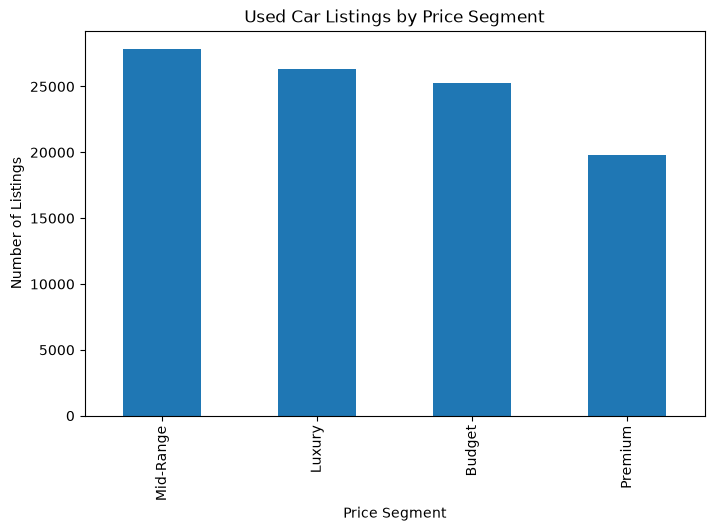

In [14]:
df["price_segment"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Used Car Listings by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Listings")

plt.show()

### Insight

The used-car market can be divided into four price segments: Budget, Mid-Range, Premium, and Luxury. The distribution shows where most listings are concentrated and provides a foundation for budget-based car recommendations.

In [15]:
df.columns.tolist()

['Unnamed: 0',
 'model',
 'year',
 'price',
 'transmission',
 'mileage',
 'fuelType',
 'tax',
 'mpg',
 'engineSize',
 'Make',
 'price_segment']

In [16]:
brand_price = df.groupby("Make")["price"].median().sort_values(ascending=False)

brand_price

Make
merc        22480.0
BMW         20462.0
Audi        20200.0
VW          15497.0
skoda       12998.0
hyundi      11990.0
ford        11291.0
toyota      10795.0
vauxhall     9999.0
Name: price, dtype: float64

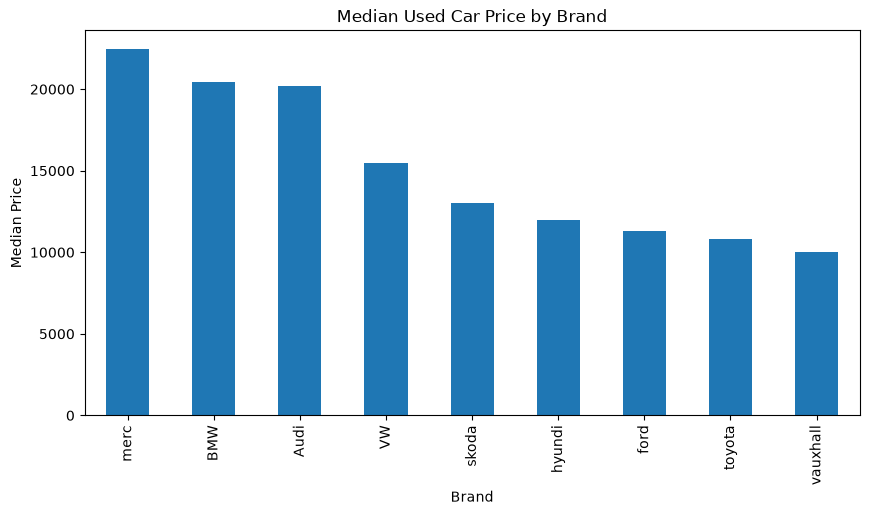

In [17]:
brand_price.plot(kind="bar", figsize=(10, 5))

plt.title("Median Used Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Median Price")

plt.show()

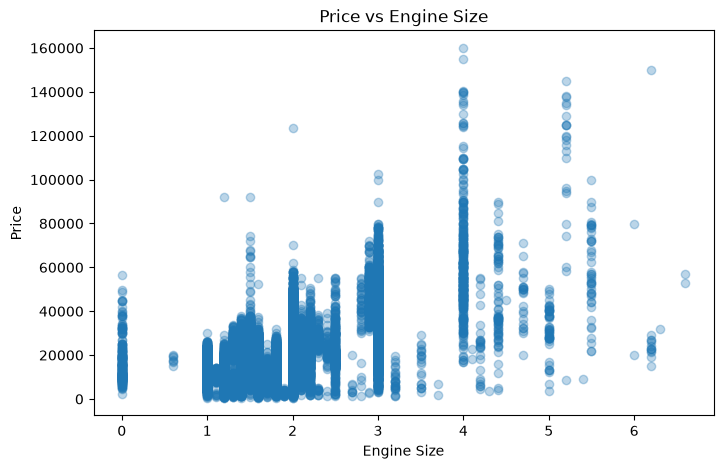

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["engineSize"], df["price"], alpha=0.3)

plt.title("Price vs Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.show()

In [19]:
fuel_segment = pd.crosstab(df["fuelType"], df["price_segment"])

fuel_segment

price_segment,Budget,Mid-Range,Premium,Luxury
fuelType,,,,
Diesel,6005,9981,10388,14554
Electric,0,1,5,0
Hybrid,139,903,845,1191
Other,56,53,65,73
Petrol,19031,16907,8516,10474


In [20]:
transmission_segment = pd.crosstab(
    df["transmission"],
    df["price_segment"]
)

transmission_segment

price_segment,Budget,Mid-Range,Premium,Luxury
transmission,,,,
Automatic,1692,4298,5004,9062
Manual,22782,20310,9796,3557
Other,0,4,4,1
Semi-Auto,757,3233,5015,13672


In [21]:
brand_segment = pd.crosstab(
    df["Make"],
    df["price_segment"]
)

brand_segment

price_segment,Budget,Mid-Range,Premium,Luxury
Make,,,,
Audi,611,2051,2655,5351
BMW,702,2167,2454,5458
VW,3013,4351,3502,4291
ford,6709,6650,3779,827
hyundi,2002,1440,935,483
merc,368,1567,3318,7866
skoda,1877,2151,1196,1043
toyota,3022,2072,785,859
vauxhall,6927,5396,1195,114
